# Fig 4: Tara Metagenomic Modules — Gated SCiFI Results

Predicting nitrate/oxygen/temperature from KEGG module abundances using GatedModel.

In [1]:
%cd /home/schmittms/project_vitelli_matthew/scifi_public/fig4_tara_metagenomics/

import sys, os
sys.path.insert(0, '/home/schmittms/project_vitelli_matthew/scifi_public/')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import scipy.ndimage
from tqdm.autonotebook import tqdm
from glob import glob
from sklearn.linear_model import LinearRegression
import re


def smooth(x, sigma=10):
    return scipy.ndimage.gaussian_filter1d(x, sigma=sigma, axis=0, mode='reflect')

from utils.models import GatedModel
from dataset import TaraDatasetMetagenomicModules

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
plt.rcParams['figure.figsize'] = [3, 2]
plt.rcParams['figure.dpi'] = 200
plt.rcParams['svg.fonttype'] = 'none'

device = torch.device('cpu')

%load_ext autoreload
%autoreload 2
%matplotlib inline
pd.options.display.max_columns = None


/project/vitelli/matthew/scifi_public/fig4_tara_metagenomics


/project/vitelli/matthew/torch_venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
/scratch/local/jobs/48048936/ipykernel_61639/2055878446.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Define model roots and load checkpoints

In [2]:
masterroot = './trained_models'
#np.sort(os.listdir(masterroot))

In [3]:
masterroot = './trained_models'

subroots = ['gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_16',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_18',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_20',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_22',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_24',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_30',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_32',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_34',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_36',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_40',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_42',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_46',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_0',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_2',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_6',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_8',
       'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_14',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_17',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_19',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_21',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_23',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_25',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_31',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_33',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_35',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_37',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_41',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_45',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_47',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_1',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_3',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_7',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_9',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_13',
       'gatedgumbel_260408_213751_targets-nitrate_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_15',
       'gatedgumbel_260408_213752_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_26',
       'gatedgumbel_260408_213752_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_28',
       'gatedgumbel_260408_213752_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_38',
       'gatedgumbel_260408_213752_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_44',
       'gatedgumbel_260408_213752_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_4',
       'gatedgumbel_260408_213752_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_10',
       'gatedgumbel_260408_213752_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_12',
       'gatedgumbel_260408_213752_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_27',
       'gatedgumbel_260408_213752_targets-nitrate_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_29',
       'gatedgumbel_260408_213752_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-3_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_43',
       'gatedgumbel_260408_213752_targets-nitrate_N-128_L-2_DO-0._LR-1e-2_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_5',
       'gatedgumbel_260408_213752_targets-nitrate_N-128_L-2_DO-0._LR-1e-3_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_11',
       'gatedgumbel_260408_213753_targets-nitrate_N-128_L-2_DO-0.1_LR-1e-2_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_39']

print(f'{len(subroots)} model directories')
subroots[:5]

48 model directories


['gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_16',
 'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-2_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_18',
 'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-3_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_20',
 'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-2_gateLR-1e-3_beta-1e-2_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_22',
 'gatedgumbel_260408_213751_targets-nitrate,Oxygen,Temperature_N-128_L-2_DO-0.05_LR-1e-3_gateLR-1e-2_beta-1e-1_TAU-2._0.9999_0.1_ACT-gelu_NENS-15_Nsteps-30000_24']

In [4]:
x['model_kwargs'][2]

NameError: name 'x' is not defined

In [5]:
records = []
x_last = None

for sr in tqdm(subroots):
    root = os.path.join(masterroot, sr)
    files = [f for f in os.listdir(root) if f.endswith('.pt') or f.endswith('.pth')]
    for file in files:
        fpath = os.path.join(root, file)
        try:
            x = torch.load(fpath, map_location=device)
        except Exception as e:
            print(f"Error loading {fpath}: {e}")
            continue
        x_last = x

        beta_match = re.search(r'beta-([^_]+)', sr)
        beta = float(beta_match.group(1)) if beta_match else np.nan

        npcs = int(file.split('_')[0].split('-')[-1])
        ensidx = int(file.split('_')[1].split('-')[-1].split('.')[0])

        pred = np.asarray(x.get('pred_train', []))
        targ = np.asarray(x.get('target_train', []))
        test_pred = np.asarray(x.get('pred_test', []))
        test_targ = np.asarray(x.get('target_test', []))

        tauparams = {'tau_' + k: v for k, v in x.get('tau_hparams', {}).items()}

        records.append({
            'npcs': npcs,
            'outputs': ','.join(x.get('train_dataset_kwargs', {}).get('targets', [])),
            'ensidx': ensidx,
            'tau': x.get('curr_tau', np.nan),
            'train_loss': x.get('train_losses', []), 'test_loss': x.get('test_losses', []),
            'train_preds': pred.squeeze() if pred.size else pred,
            'train_targets': targ.squeeze() if targ.size else targ,
            'test_preds': test_pred.squeeze() if test_pred.size else test_pred,
            'test_targets': test_targ.squeeze() if test_targ.size else test_targ,
            'r2_test': x.get('r2_test', np.nan),
            'r2_train': x.get('r2_train', np.nan),
            'proj': np.asarray(x.get('proj', np.nan)),
            'proj_det': np.asarray(x.get('proj_det', np.nan)),
            'gate': np.asarray(x.get('gate', np.nan)),
            'logits': np.asarray(x.get('proj_logits', np.nan)),
            'lr': x.get('model_kwargs', {}).get(1, {}).get('optimizer_hparams', {}).get('LR', np.nan),
            'gate_lr': x.get('model_kwargs', {}).get(1, {}).get('optimizer_hparams', {}).get('gate_LR', np.nan),
            'beta': x.get('beta', beta),
            'dropout': x.get('model_kwargs', {}).get(1, {}).get('network_hparams', {}).get('dropout', np.nan),
            'seed': x.get('seed', np.nan),
            **tauparams
        })


loss_df = pd.DataFrame(records)

if x_last is None:
    raise RuntimeError('No checkpoints were loaded.')

train_kwargs = dict(x_last['train_dataset_kwargs'])
train_kwargs['targets'] = ['nitrate', 'Oxygen', 'Temperature']
train_kwargs['device'] = device
dataset_train = TaraDatasetMetagenomicModules(**train_kwargs)

print(loss_df.shape)
loss_df.head()

  0%|          | 0/48 [00:00<?, ?it/s]

(5760, 24)


,npcs,outputs,ensidx,tau,train_loss,test_loss,train_preds,train_targets,test_preds,test_targets,r2_test,r2_train,proj,proj_det,gate,logits,lr,gate_lr,beta,dropout,seed,tau_init,tau_relax_rate,tau_min
0,4,"nitrate,Oxygen,Temperature",6,0.099998,"[1.1119362, 1.0589583, 0.9132041, 0.84831434, ...","[1.3156003, 1.3161083, 1.2795527, 1.251881, 1....","[[0.049353343, 2.9687543, 2.9569237], [0.09484...","[[0.03780412, 3.1567776, 2.5226057], [0.118558...","[[0.090808704, 3.0015335, 2.9430482], [0.33730...","[[0.56405324, 2.8425133, 3.5429366], [1.350716...",0.637184,0.980029,"[[2.7419245e-09, 1.2367375e-10, 0.78639513, 0....","[[0.24026376, 0.24822065, 0.22821237, 0.283303...","[[0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0....","[[-0.021907441, 0.010673319, -0.07336811, 0.14...",0.01,0.01,0.1,0.05,1016,2.0,0.9999,0.1
1,1,"nitrate,Oxygen,Temperature",1,0.099998,"[1.3324146, 1.2345506, 1.1579399, 0.99108416, ...","[1.3629601, 1.5065283, 1.2589796, 1.2249811, 1...","[[1.5933316, 3.1265056, 1.2116534], [0.0600599...","[[2.6134672, 4.7306886, -0.10210221], [0.01693...","[[0.22500463, 2.8116536, 3.0462165], [1.869539...","[[0.012980573, 2.657712, 3.5703921], [0.319125...",0.133398,0.783765,"[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0....","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0....",0.01,0.01,0.1,0.05,1016,2.0,0.9999,0.1
2,8,"nitrate,Oxygen,Temperature",5,0.099998,"[1.0144957, 0.985569, 0.93772995, 0.8511422, 0...","[0.73411757, 0.69945085, 0.8000571, 0.6879836,...","[[0.14706689, 2.8407307, 3.034067], [2.7108645...","[[0.07020263, 2.9066498, 3.4269314], [2.819287...","[[0.15238956, 2.8451333, 3.027509], [0.1523895...","[[0.01927838, 2.7994144, 3.2522445], [0.194744...",0.615067,0.816788,"[[9.878568e-05, 4.157796e-11, 1.8883622e-13, 4...","[[0.15075094, 0.10053144, 0.11248053, 0.134791...","[[0.0], [0.0], [0.0], [1.0], [0.0], [1.0], [0....","[[0.21681428, -0.18834427, -0.07603464, 0.1049...",0.01,0.01,0.1,0.05,1016,2.0,0.9999,0.1
3,6,"nitrate,Oxygen,Temperature",0,0.099998,"[1.4299264, 1.0119792, 0.9894473, 0.86680156, ...","[1.1706053, 1.0356944, 1.0269707, 0.9887619, 0...","[[0.14498779, 2.8910584, 2.9800959], [0.144987...","[[0.0015623766, 2.7629898, 3.5228274], [0.0347...","[[0.14498779, 2.8910584, 2.9800959], [0.144987...","[[0.023130238, 3.1695151, 2.3963115], [0.00024...",0.569803,0.851574,"[[3.676394e-09, 3.3681804e-11, 0.9871551, 1.67...","[[0.16372734, 0.17379153, 0.16474737, 0.172804...","[[0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0....","[[-0.015587653, 0.044066366, -0.00937686, 0.03...",0.01,0.01,0.1,0.05,1016,2.0,0.9999,0.1
4,3,"nitrate,Oxygen,Temperature",10,0.099998,"[1.3569626, 1.254311, 1.0626723, 1.0495191, 0....","[1.0708293, 0.9116632, 0.99932575, 0.94896406,...","[[2.6506102, 3.1108093, 0.38668942], [0.900470...","[[2.6134672, 4.7306886, -0.10210221], [0.00682...","[[0.19463123, 2.9863212, 2.825983], [0.1946312...","[[0.01927838, 2.7994144, 3.2522445], [0.005397...",0.456924,0.608706,"[[2.796202e-05, 0.8761184, 0.123853624], [1.0,...","[[0.30595973, 0.38234603, 0.31169418], [0.3228...","[[0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0....","[[-0.06466093, 0.15821163, -0.046091937], [-0....",0.01,0.01,0.1,0.05,1016,2.0,0.9999,0.1


In [6]:
# get all unique hparam combos
# Get all sets of hyperparameters
hyperparams = loss_df[['lr', 'dropout', 'tau_relax_rate', 'gate_lr', 'beta', 
                       #'outputs'
                       ]].drop_duplicates()
print(f'Found {len(hyperparams)} unique hyperparameter combinations')
hyperparams

Found 24 unique hyperparameter combinations


,lr,dropout,tau_relax_rate,gate_lr,beta
0,0.010,0.05,0.9999,0.010,0.10
120,0.010,0.05,0.9999,0.010,0.01
240,0.010,0.05,0.9999,0.001,0.10
360,0.010,0.05,0.9999,0.001,0.01
480,0.001,0.05,0.9999,0.010,0.10
600,0.001,0.05,0.9999,0.001,0.01
720,0.010,0.10,0.9999,0.010,0.10
840,0.010,0.10,0.9999,0.010,0.01
960,0.010,0.10,0.9999,0.001,0.10
1080,0.001,0.10,0.9999,0.010,0.10


## Load pathway annotations and configure main hparams

In [8]:
module_pathway_map = pd.read_pickle('/home/schmittms/soil_microbiome_model_reduction/function_driven_clustering/tara/annotations/module_pathway_annotation.pkl')
module_list = pd.read_csv('/project/vitelli/matthew/soil_microbiome_model_reduction/tara_data/metagenomics/kegg_old_module_list_2017.txt', sep='\t')

modpath, moddesc, modsubpath = {}, {}, {}
for _, row in module_pathway_map.iterrows():
    for mod, desc in zip(row['modules'], row['desc']):
        modpath[mod] = modpath.get(mod, []) + [row['class']]
        moddesc[mod] = ' '.join(desc.split()[1:-1])
        modsubpath[mod] = modsubpath.get(mod, []) + [row['pathway']]

modpath = {k: max(set(v), key=v.count) for k, v in modpath.items()}
modsubpath = {k: max(set(v), key=v.count) for k, v in modsubpath.items()}

abd = dataset_train.inputs.detach().cpu().numpy()
nitrate = dataset_train.targets[:, 0].detach().cpu().numpy()
oxygen = dataset_train.targets[:, 1].detach().cpu().numpy()
temp = dataset_train.targets[:, 2].detach().cpu().numpy()

nitrate = nitrate - np.nanmean(nitrate)
oxygen = oxygen - np.nanmean(oxygen)
temp = temp - np.nanmean(temp)

depth = dataset_train.df.loc[~dataset_train.nan_samples.detach().cpu().numpy(), 'Depth'].values
depth_bin_edges = np.linspace(np.min(depth) - 1e-5, np.max(depth) + 1e-5, 10)
depth_bin_centers = 0.5 * (depth_bin_edges[1:] + depth_bin_edges[:-1])

main_hparams = {
    'DO': 0.05,
    'lr': 0.01,
    'gate_lr': 1e-3,
    'beta': 1e-1,
    'r': 0.9999,
    'npc': 3,
    'n_ensemble_keep': 7,
    'outputs': 'nitrate,Oxygen,Temperature'
}

mask_main = ((loss_df.dropout == main_hparams['DO']) & (loss_df.npcs == main_hparams['npc']) &
             (loss_df.lr == main_hparams['lr']) & (loss_df.outputs == main_hparams['outputs']) &
             (loss_df.gate_lr == main_hparams['gate_lr']) & (loss_df.beta == main_hparams['beta']))

if np.sum(mask_main) == 0:
    # Fallback: keep requested outputs/npc and choose the best available combo by median r2_test.
    cand = loss_df[(loss_df.npcs == main_hparams['npc']) & (loss_df.outputs == main_hparams['outputs'])].copy()
    if len(cand) == 0:
        raise RuntimeError('No runs available for requested outputs/npc in main_hparams.')
    grp_cols = ['dropout', 'lr', 'gate_lr', 'beta']
    best = cand.groupby(grp_cols, dropna=False)['r2_test'].median().sort_values(ascending=False).index[0]
    main_hparams['DO'], main_hparams['lr'], main_hparams['gate_lr'], main_hparams['beta'] = best
    mask_main = ((loss_df.dropout == main_hparams['DO']) & (loss_df.npcs == main_hparams['npc']) &
                 (loss_df.lr == main_hparams['lr']) & (loss_df.outputs == main_hparams['outputs']) &
                 (loss_df.gate_lr == main_hparams['gate_lr']) & (loss_df.beta == main_hparams['beta']))
    print('No exact main_hparams match. Using best available:', main_hparams)

test_r2 = loss_df.loc[mask_main, 'r2_test'].values
ens_sorted = loss_df.loc[mask_main, 'ensidx'].values[np.argsort(test_r2)[::-1]]
ens_sorted = ens_sorted[:main_hparams['n_ensemble_keep']]

if len(ens_sorted) == 0:
    raise RuntimeError('No ensembles matched main_hparams.')

def get_proj_gate(ens_idx):
    proj = loss_df.loc[mask_main & (loss_df.ensidx == ens_idx), 'proj_det'].values[0].copy()
    gate = loss_df.loc[mask_main & (loss_df.ensidx == ens_idx), 'gate'].values[0].copy()
    proj[np.arange(len(proj)), np.argmax(proj, axis=1)] = 1
    proj[proj < 1] = 0
    return proj, gate

print(f'ens_sorted: {ens_sorted}')

ens_sorted: [10 12  4 14  9  6  1]


## Pre-compute all figure data

In [9]:
# ---- Figure A: Error vs N components ----
outputs_list = ['nitrate', 'nitrate,Oxygen,Temperature']
npc_unique = np.sort(loss_df.npcs.unique())
error_plot_data = {}
for outputs_name in outputs_list:
    for npc in npc_unique:
        vals = []
        for ens in loss_df.ensidx.unique():
            mask = ((loss_df.npcs == npc) & (loss_df.ensidx == ens) & (loss_df.lr == main_hparams['lr']) &
                    (loss_df.dropout == main_hparams['DO']) & (loss_df.outputs == outputs_name) &
                    (loss_df.gate_lr == main_hparams['gate_lr']) & (loss_df.beta == main_hparams['beta']))
            if np.sum(mask) == 0:
                continue
            loss_all = loss_df.loc[mask, 'test_loss'].values[0]
            vals.append(np.quantile(loss_all[-100:], q=0.1))
        error_plot_data[(outputs_name, npc)] = np.asarray(vals)

# ---- Figure B: Groups vs depth ----
gp_avgs_by_depth = np.zeros((len(ens_sorted), main_hparams['npc'], len(depth_bin_edges) - 1))
for e, ens_idx in enumerate(ens_sorted):
    proj, gate = get_proj_gate(ens_idx)
    R2s = np.zeros((3, main_hparams['npc']))
    slopes = np.zeros((3, main_hparams['npc']))
    for i in range(main_hparams['npc']):
        idx = proj[:, i] * gate[:, 0] > 0.5
        intragroup_abd = abd[:, idx] * gate[None, idx, 0]
        gp_abd = np.sum(intragroup_abd, axis=1)
        if np.all(gp_abd == 0):
            continue
        abd_hist, _ = np.histogram(depth, bins=depth_bin_edges, weights=gp_abd)
        abd_hist /= np.histogram(depth, bins=depth_bin_edges)[0] + 1e-10
        gp_avgs_by_depth[e, i] = abd_hist
        reg = LinearRegression().fit(gp_abd[:, None], nitrate)
        R2s[0][i] = reg.score(gp_abd[:, None], nitrate)
        slopes[0][i] = reg.coef_[0]
    group_sort = np.argsort(R2s[0] * np.sign(slopes[0]))
    gp_avgs_by_depth[e] = gp_avgs_by_depth[e][group_sort]

mean_gps_by_depth = np.nanmean(gp_avgs_by_depth, axis=0)
std_gps_by_depth = np.nanstd(gp_avgs_by_depth, axis=0)
mean_gps_by_depth = mean_gps_by_depth - np.mean(mean_gps_by_depth, axis=1, keepdims=True)
scale = np.std(mean_gps_by_depth, axis=1, keepdims=True)
mean_gps_by_depth = mean_gps_by_depth / scale
std_gps_by_depth = std_gps_by_depth / scale

env_depth_profiles = {}
for name, var in [('Nitrate', nitrate), ('Oxygen', oxygen), ('Temperature', temp)]:
    var_hist, _ = np.histogram(depth, bins=depth_bin_edges, weights=var)
    var_hist /= np.histogram(depth, bins=depth_bin_edges)[0] + 1e-10
    var2_hist, _ = np.histogram(depth, bins=depth_bin_edges, weights=var**2)
    var2_hist /= np.histogram(depth, bins=depth_bin_edges)[0] + 1e-10
    std_hist = np.sqrt(var2_hist - var_hist**2)
    env_depth_profiles[name] = (var, var_hist, std_hist)

# ---- Figure C: Correlation boxplots ----
corr_mat = []
for ens_idx in ens_sorted:
    proj, gate = get_proj_gate(ens_idx)
    R2s = np.zeros((3, main_hparams['npc']))
    corrs = np.zeros((3, main_hparams['npc']))
    for i in range(main_hparams['npc']):
        idx = proj[:, i] * gate[:, 0] > 0.5
        gp_abd = np.sum(abd[:, idx], axis=1)
        if np.all(gp_abd == 0):
            continue
        for r, var in enumerate([nitrate, oxygen, temp]):
            reg = LinearRegression().fit(gp_abd[:, None], var)
            R2s[r][i] = reg.score(gp_abd[:, None], var)
            corrs[r][i] = np.corrcoef(gp_abd, var)[0, 1]
    group_sort = np.argsort(R2s[0] * np.sign(corrs[0]))[::-1]
    corr_mat.append(corrs[:, group_sort])
corr_mat = np.asarray(corr_mat)

# ---- Figure D/E: Module assignments ----
THRESHOLD = 0.7
MIN_DIFF_THRESHOLD = 0.05

idx_to_keep_all_ens = np.zeros((main_hparams['n_ensemble_keep'], abd.shape[1]), dtype=bool)
for e, ens_idx in enumerate(ens_sorted):
    proj, gate = get_proj_gate(ens_idx)
    idx_to_keep_all_ens[e] = np.any(proj * gate > 0.5, axis=1)

idx_to_keep = np.sum(idx_to_keep_all_ens, axis=0) >= (THRESHOLD * main_hparams['n_ensemble_keep'])
idx_to_keep = np.array([idx and (modsubpath.get(m) is not None) for idx, m in zip(idx_to_keep, dataset_train.module_names)])
module_names_kept = dataset_train.module_names[idx_to_keep]
module_desc_kept = [
    f"{m}: {moddesc[m]}" if m in moddesc else (f"{m}: {modsubpath[m]}" if m in modsubpath else f"{m}: n/a")
    for m in module_names_kept
]
n_modules_kept = int(np.sum(idx_to_keep))

frac_of_path_in_group = np.zeros((len(ens_sorted), n_modules_kept, main_hparams['npc']))
for e, ens_idx in enumerate(ens_sorted):
    proj, gate = get_proj_gate(ens_idx)
    R2s = np.zeros((3, main_hparams['npc']))
    slopes = np.zeros((3, main_hparams['npc']))
    for i in range(main_hparams['npc']):
        idx = (proj[idx_to_keep, i] * gate[idx_to_keep, 0] > 0.5)
        intragroup_abd = abd[:, idx_to_keep][:, idx]
        intragroup_abd *= gate[idx_to_keep, 0][idx]
        frac_of_path_in_group[e, idx, i] += np.mean(intragroup_abd, axis=0)
        gp_abd = np.sum(abd[:, idx_to_keep][:, idx], axis=1)
        if np.all(gp_abd == 0):
            continue
        reg = LinearRegression().fit(gp_abd[:, None], nitrate)
        R2s[0][i] = reg.score(gp_abd[:, None], nitrate)
        slopes[0][i] = reg.coef_[0]
    group_sort = np.argsort(R2s[0] * np.sign(slopes[0]))
    frac_of_path_in_group[e] = frac_of_path_in_group[e][:, group_sort]

frac_of_path_in_group[:, :, 1:-1] = np.sum(frac_of_path_in_group[:, :, 1:-1], axis=-1)[:, :, None]
mean_assignments_mod = np.mean(frac_of_path_in_group, axis=0)[:, ::-1]
std_assignments_mod = np.std(frac_of_path_in_group, axis=0)[:, ::-1]
p_sort_mod = np.argsort(mean_assignments_mod[:, 0] - mean_assignments_mod[:, -1])
mean_assignments_mod = mean_assignments_mod[p_sort_mod]
std_assignments_mod = std_assignments_mod[p_sort_mod]
module_desc_sorted = np.asarray(module_desc_kept)[p_sort_mod]

mask_by_min_abd_difference = ((np.abs(mean_assignments_mod[:, 0] - mean_assignments_mod[:, -1]) > MIN_DIFF_THRESHOLD) |
                              (np.abs(mean_assignments_mod[:, 1]) > MIN_DIFF_THRESHOLD))
mean_assignments_mod_filt = mean_assignments_mod[mask_by_min_abd_difference]
std_assignments_mod_filt = std_assignments_mod[mask_by_min_abd_difference]
module_desc_sorted_filt = module_desc_sorted[mask_by_min_abd_difference]

# ---- Figure F: Pathway assignments ----
MIN_PLOT_ABD = 0.05
pathway_abundances = {}
for ens_idx in ens_sorted:
    proj, gate = get_proj_gate(ens_idx)
    idx = np.any(proj * gate > 0.5, axis=1)
    modulelabels = dataset_train.module_names[idx]
    pathlabels = ['n/a' if (lbl not in module_list.Module.unique()) or (modsubpath.get(lbl) is None) else modsubpath[lbl] for lbl in modulelabels]
    for pathway in pathlabels:
        moduleabd = [np.sum(x) if pathway in pth else 0 for pth, x in zip(pathlabels, abd[:, idx].T)]
        pathway_abundances[pathway] = pathway_abundances.get(pathway, 0) + np.sum(moduleabd)

ar = np.asarray([[path, val] for path, val in pathway_abundances.items() if val > 0], dtype=object)
pathways = ar[np.argsort(ar[:, 1].astype(float))[::-1]][:, 0] if len(ar) else np.array([])
pathways = np.sort(pathways)[::-1]
pathways = pathways[pathways != 'n/a']

frac_path = np.zeros((len(ens_sorted), len(pathways), main_hparams['npc']))
for e, ens_idx in enumerate(ens_sorted):
    proj, gate = get_proj_gate(ens_idx)
    R2s = np.zeros((3, main_hparams['npc']))
    slopes = np.zeros((3, main_hparams['npc']))
    for i in range(main_hparams['npc']):
        idx = proj[:, i] * gate[:, 0] > 0.75
        intragroup_abd = abd[:, idx] * gate[None, idx, 0]
        modulelabels = dataset_train.module_names[idx]
        pathlabels = ['n/a' if (lbl not in module_list.Module.unique()) or (modsubpath.get(lbl) is None) else modsubpath[lbl] for lbl in modulelabels]
        for j, pathway in enumerate(pathways):
            moduleabd = [np.asarray(x) for pth, x in zip(pathlabels, intragroup_abd.T) if pathway in pth]
            if not moduleabd:
                continue
            frac_path[e, j, i] += np.sum(moduleabd) / intragroup_abd.shape[0]
        gp_abd = np.sum(abd[:, idx], axis=1)
        if np.all(gp_abd == 0):
            continue
        reg = LinearRegression().fit(gp_abd[:, None], nitrate)
        R2s[0][i] = reg.score(gp_abd[:, None], nitrate)
        slopes[0][i] = reg.coef_[0]
    group_sort = np.argsort(R2s[0] * np.sign(slopes[0]))
    frac_path[e] = frac_path[e][:, group_sort]

if len(pathways) > 0:
    frac_path[:, :, 1:-1] = np.sum(frac_path[:, :, 1:-1], axis=-1)[:, :, None]

mean_assignments_path = np.mean(frac_path, axis=0)[:, ::-1] if len(pathways) else np.zeros((0, main_hparams['npc']))
std_assignments_path = np.std(frac_path, axis=0)[:, ::-1] if len(pathways) else np.zeros((0, main_hparams['npc']))
p_sort_path = np.argsort(mean_assignments_path[:, 0] - mean_assignments_path[:, -1]) if len(pathways) else np.array([], dtype=int)
mean_assignments_path = mean_assignments_path[p_sort_path] if len(pathways) else mean_assignments_path
std_assignments_path = std_assignments_path[p_sort_path] if len(pathways) else std_assignments_path
pathways_sorted = pathways[p_sort_path] if len(pathways) else pathways

if len(pathways_sorted):
    mask_above_min = np.max(np.abs(mean_assignments_path[:, :, None] - mean_assignments_path[:, None, :]), axis=(-1, -2)) > MIN_PLOT_ABD
    max_grp = np.argmax(mean_assignments_path, axis=1)
    mask_above_min &= mean_assignments_path[np.arange(len(mean_assignments_path)), max_grp] - std_assignments_path[np.arange(len(std_assignments_path)), max_grp] >= 0
    mean_assignments_path = mean_assignments_path[mask_above_min]
    std_assignments_path = std_assignments_path[mask_above_min]
    pathways_sorted = pathways_sorted[mask_above_min]

print('Computation complete.')
print(f'Ensembles used: {len(ens_sorted)}')
print(f'Modules kept: {n_modules_kept}')
print(f'Pathways kept (thresholded figure): {len(pathways_sorted)}')

Computation complete.
Ensembles used: 7
Modules kept: 47
Pathways kept (thresholded figure): 22


## Fig 4a: Test error vs N components (all outputs)

[0.55905446 0.40222316 0.46427886 0.65295843 0.49189949 0.61329259
 0.48833541 0.27834293 0.30873607 0.45974011 0.41032934 0.20009349
 0.80827355 0.70624778 0.8183048 ]
[0.28627003 0.20559727 0.16289705 0.43963148 0.32777689 1.97012212
 0.15917777 0.12757618 0.11221558 0.5408704  0.55368644 0.08058539
 0.16250538 0.28105802 0.23591422]
[0.155846   0.16938408 0.1851473  0.46317596 0.43635618 0.46278163
 0.09643302 0.114341   0.09179085 0.13558525 0.40263637 0.04202008
 0.39250559 0.2211749  0.25001087]
[0.11767651 0.20809037 0.20227132 0.30618418 0.37460755 0.20124008
 0.08580684 0.07588199 0.08256812 0.41346193 0.39800852 0.06155908
 0.16490506 0.18046305 0.15122694]
[0.13651232 0.12104144 0.10429169 0.3579402  0.4539924  0.51985119
 0.08066832 0.06593299 0.07398641 0.30065809 0.41397995 0.04566088
 0.13130851 0.0884922  0.25982329]
[0.11814394 0.16656007 0.10998571 0.08515976 0.42355554 0.4465149
 0.08835381 0.09682225 0.05983149 0.36511899 0.33265729 0.02648302
 0.1533349  0.20845246

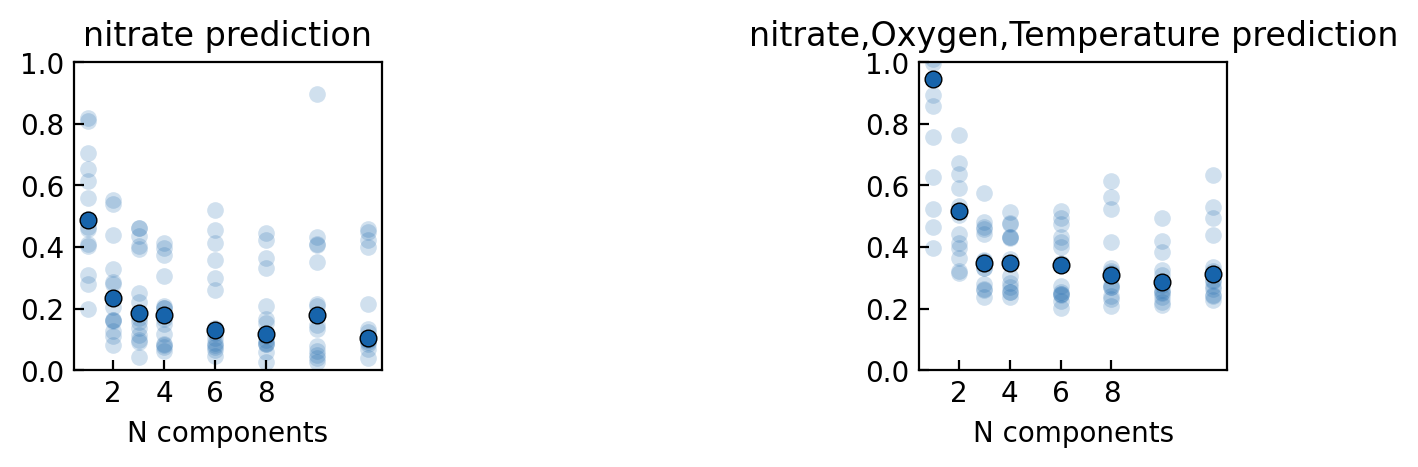

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 2), dpi=200)
for i, outputs_name in enumerate(outputs_list):
    for npc in npc_unique:
        vals = error_plot_data[(outputs_name, npc)]
        print(vals)
        if len(vals) == 0:
            continue
        ax[i].scatter(npc * np.ones(len(vals)), vals, color=plt.get_cmap('Blues')(0.8), lw=0., alpha=0.2)
        ax[i].scatter(npc, np.median(vals), color=plt.get_cmap('Blues')(0.8), edgecolor='k', lw=0.5)
    ax[i].set_title(f'{outputs_name} prediction')
    ax[i].set_ylim(0, 1)
    ax[i].set_xlabel('N components')
    ax[i].tick_params(direction='in')
    ax[i].set_box_aspect(1)
    ax[i].set_xticks([2, 4, 6, 8])

if input('save? ').strip().lower() == 'save':
    fig.savefig(f'./figures/gated_Error_v_N_all_outputs_beta_{main_hparams["beta"]}.svg', bbox_inches='tight')

## Fig 4b: Groups vs depth

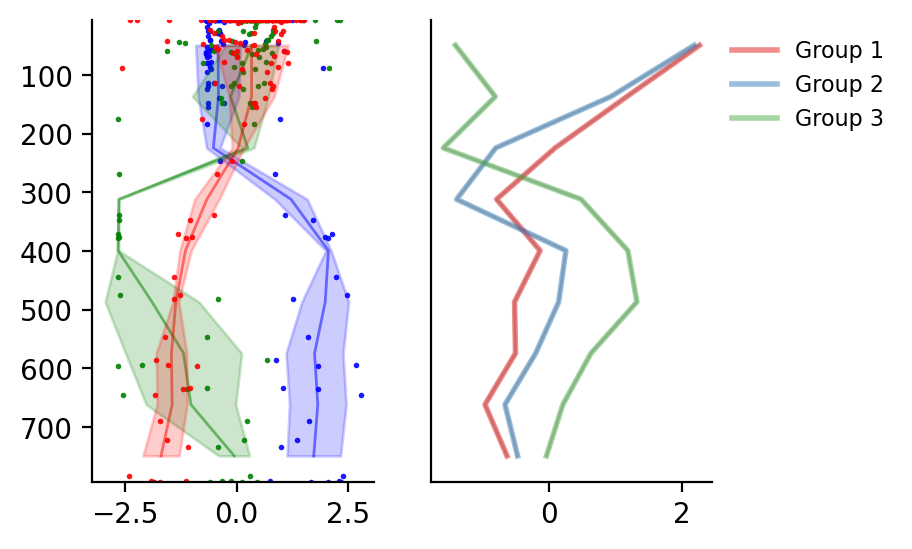

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(4, 3), dpi=200, gridspec_kw={'width_ratios': [1, 1]})

for i, clr in zip(range(main_hparams['npc']), ['C0', 'C1', 'C2', 'C3']):
    ax[1].plot(mean_gps_by_depth[i], depth_bin_centers, color='gray', alpha=0.5, lw=1, zorder=-1)
    ax[1].plot(mean_gps_by_depth[i], depth_bin_centers, color=clr, alpha=0.5, lw=2, label=f'Group {i + 1}')
ax[1].legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)

for title, clr in [('Nitrate', 'blue'), ('Oxygen', 'green'), ('Temperature', 'red')]:
    var, var_hist, std_hist = env_depth_profiles[title]
    ax[0].scatter(var, depth, color=clr, alpha=0.9, lw=0, s=4)
    ax[0].plot(var_hist, depth_bin_centers, color=clr, alpha=0.5, lw=1, zorder=-1)
    ax[0].fill_betweenx(depth_bin_centers, var_hist - std_hist, var_hist + std_hist, color=clr, alpha=0.2)

for a in ax:
    a.set_ylim(np.max(depth_bin_edges), np.min(depth_bin_edges) - 0.1)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
for a in ax[1:]:
    a.set_yticklabels([])
    a.set_yticks([])

if input('save? ').strip().lower() == 'save':
    fig.savefig('./figures/groups_vs_depth.svg', bbox_inches='tight')

## Fig 4c: Correlation boxplots

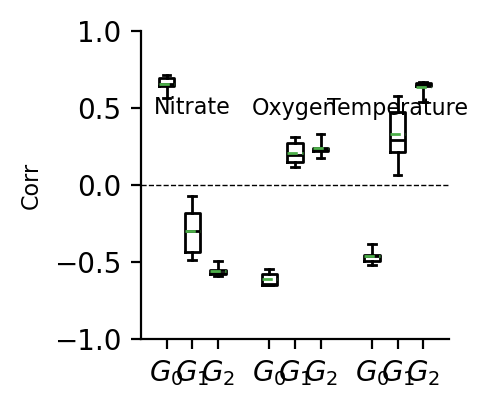

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=200)
for r in range(3):
    ax.boxplot(corr_mat[:, r, :], positions=np.linspace(0, 1, main_hparams['npc']) - 0.5 + 2 * r,
               whis=(0, 100), widths=0.3, showmeans=True, meanline=True,
               boxprops=dict(color='k'), medianprops=dict(color='k'),
               whiskerprops=dict(color='k'), capprops=dict(color='k'))

xticks = np.concatenate([np.linspace(0, 1, main_hparams['npc']) - 0.5 + 2 * r for r in range(3)])
xticklabels = [f'$G_{i}$' for _ in range(3) for i in range(main_hparams['npc'])]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.text(0., 0.5, 'Nitrate', fontsize=8, ha='center', va='center')
ax.text(2., 0.5, 'Oxygen', fontsize=8, ha='center', va='center')
ax.text(4., 0.5, 'Temperature', fontsize=8, ha='center', va='center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Corr', fontsize=8)
ax.axhline(0, color='k', linestyle='--', lw=0.5)
ax.set_ylim(-1, 1)
ax.set_box_aspect(1.)

if input('save? ').strip().lower() == 'save':
    fig.savefig('./figures/gated_groups_corr_outputs.svg', bbox_inches='tight')

## Fig 4d: Module assignment (filtered by abundance difference)

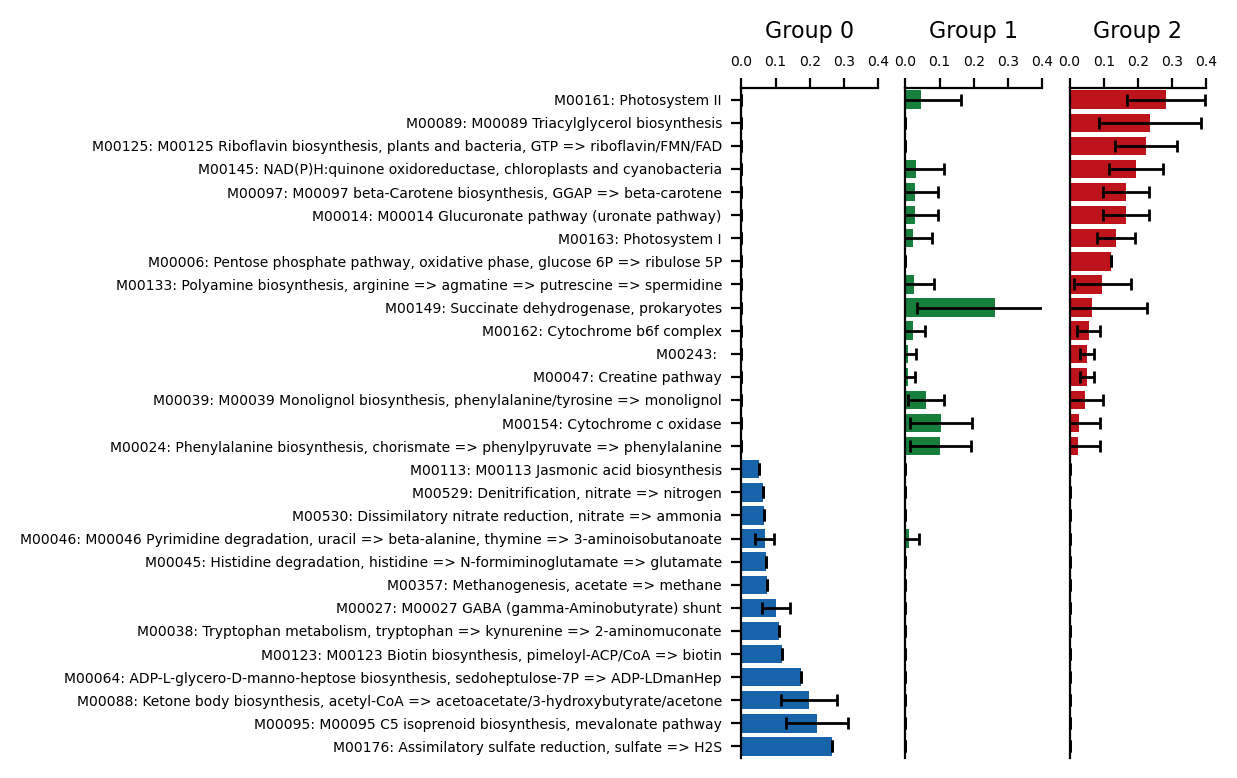

In [13]:
n_modules_plot = mean_assignments_mod_filt.shape[0]
height = 0.15 * n_modules_plot
fig, ax = plt.subplots(1, main_hparams['npc'], figsize=(3, height), dpi=200)

for r, cmap in zip(range(main_hparams['npc']), ['Blues', 'Greens', 'Reds']):
    ax[r].barh(np.arange(n_modules_plot), mean_assignments_mod_filt[:, r], color=plt.get_cmap(cmap)(0.8), lw=0)
    ax[r].errorbar(mean_assignments_mod_filt[:, r], np.arange(n_modules_plot), xerr=std_assignments_mod_filt[:, r],
                   color='k', lw=0., capsize=2, elinewidth=1)
for i, a in enumerate(ax):
    a.set_yticks([])
    a.set_yticklabels([])
    a.spines['bottom'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xticks(np.arange(0, 0.5, 0.1))
    a.set_xlim(0, 0.4)
    a.set_title(f'Group {i}', fontsize=8)
    a.tick_params(axis='x', labelsize=5)
    a.xaxis.tick_top()
    a.xaxis.set_label_position('top')
    a.set_ylim(n_modules_plot - 0.5, -0.5)
ax[0].set_yticks(np.arange(n_modules_plot))
ax[0].set_yticklabels(module_desc_sorted_filt, rotation=0, fontsize=5)

if input('save? ').strip().lower() == 'save':
    fig.savefig('./figures/fig4_module_assignment_filtered.svg', bbox_inches='tight')

## Fig 4e: Pathway assignment (thresholded)

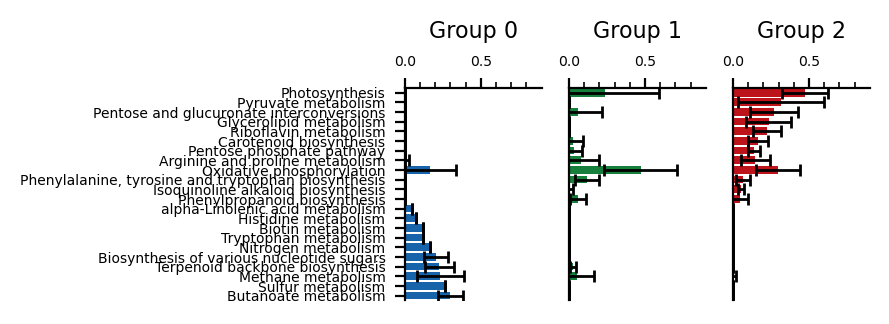

In [14]:
height = 0.06 * (1 + len(pathways_sorted))
fig, ax = plt.subplots(1, main_hparams['npc'], figsize=(3, height), dpi=200)

for r, cmap in zip(range(main_hparams['npc']), ['Blues', 'Greens', 'Reds']):
    ax[r].barh(np.arange(len(pathways_sorted)), mean_assignments_path[:, r], color=plt.get_cmap(cmap)(0.8), lw=0)
    ax[r].errorbar(mean_assignments_path[:, r], np.arange(len(pathways_sorted)), xerr=std_assignments_path[:, r],
                   color='k', lw=0., capsize=2, elinewidth=1)

for i, a in enumerate(ax):
    a.set_yticks([])
    a.set_yticklabels([])
    a.spines['bottom'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xticks(np.arange(0, 0.9, 0.1), minor=True)
    a.set_xticks([0, 0.5])
    a.set_xlim(0, 0.9)
    a.set_title(f'Group {i}', fontsize=8)
    a.set_ylim(len(pathways_sorted) - 0.5, -0.5)
    a.tick_params(axis='x', labelsize=5)
    a.xaxis.tick_top()
    a.xaxis.set_label_position('top')

ax[0].set_yticks(np.arange(len(pathways_sorted)))
ax[0].set_yticklabels(pathways_sorted, rotation=0, fontsize=5)

if input('save? ').strip().lower() == 'save':
    fig.savefig('./figures/fig4_pathway_assignment_thresholded.svg', bbox_inches='tight')